# **Text classification using pretrained word embeddings**




In [3]:
from torchtext.vocab import GloVe, vocab

C:\Users\Vish\AppData\Roaming\Python\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## **Step 1: Import Model**

In [4]:
glove_6B = GloVe(name="6B")

In [5]:
# build vocabulary
vocab = vocab(glove_6B.stoi,specials=["<unk>"])
vocab.set_default_index(vocab["<unk>"])

In [6]:
vocab(["<unk>","Hello","hello"])

[0, 0, 13075]

## **Step 2: Tokenization**

In [7]:
from torchtext.data.utils import get_tokenizer
from torchtext.datasets import AG_NEWS
from torchtext.data.functional import to_map_style_dataset  
from torch.utils.data import random_split
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from tqdm import tqdm

In [8]:
tokenizer = get_tokenizer('basic_english')

Import Dataset

In [9]:
#initialize the train and test iterators
train_iter, test_iter = AG_NEWS()

# define train and test datasets
train_dataset = to_map_style_dataset(train_iter)
test_dataset = to_map_style_dataset(test_iter)

Split train dataset into valid dataset also
 

In [10]:
num_train = int(len(train_dataset)*0.85) 

#randomly split train and valid datasets
split_train, split_valid = random_split(train_dataset,[num_train,(len(train_dataset)-num_train)])

In [11]:
# define class labels
ag_news_label = {1: "World", 2: "Sports", 3: "Business", 4: "Sci/Tec"}
num_class = len(set([label for (label,text) in train_iter]))
num_class

4

## **Step 3: Data Loader**

Define collate function

In [12]:
def text_pipeline(x):
    x = x.lower()
    return vocab(tokenizer(x))

def label_pipeline(x):
    return int(x)-1

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device.type

'cpu'

In [14]:
def collate_func(batch):
    
    label_list, text_list, offsets = [],[],[0]
    
    for _label, _text in batch:
        label_list.append(label_pipeline(_label))
        process_text = torch.tensor(text_pipeline(_text),dtype=torch.int64)
        text_list.append(process_text)
        offsets.append(process_text.size(0))
        
    
    label_list = torch.tensor(label_list,dtype=torch.int64)
    offsets = torch.tensor(offsets).cumsum(dim=0)
    text_list = torch.cat(text_list)
    
   
    
    return label_list.to(device), text_list.to(device), offsets.to(device)

In [15]:
collate_func(split_train)

(tensor([0, 3, 3,  ..., 2, 3, 0]),
 tensor([ 3440,  7578,   971,  ..., 25606,  2816,     2]),
 tensor([      0,      34,      73,  ..., 4416277, 4416326, 4416364]))

#### Define Data Loader

In [16]:
batch_size = 64

In [17]:
train_datalaoder = DataLoader(
    split_train,shuffle=True, batch_size=batch_size, collate_fn=collate_func
)

valid_dataloader = DataLoader(
    split_valid, shuffle=True, batch_size=batch_size, collate_fn=collate_func
)

test_dataloader = DataLoader(
    test_dataset, shuffle=True, batch_size=batch_size, collate_fn=collate_func
)

## **Step 4: Model Class Design**

In [18]:
class TextClassifierModel(nn.Module):
    def __init__(self, vocab_size, embedded_dim, num_class):
        super(TextClassifierModel,self).__init__()
        # define embedding layer from pre-define model
        self.embeddings = nn.Embedding.from_pretrained(glove_6B.vectors,freeze=True)
        
        #define fully connected layer
        self.fc = nn.Linear(in_features=embedded_dim, out_features=num_class)
        #define initial weights (random)
        self.init_weights()
    
    def init_weights(self):
        initrange = 0.5
        #define weights for embedding layer
        self.embeddings.weight.data.uniform_(-initrange,initrange)
        #define weights for fc layer
        self.fc.weight.data.uniform_(-initrange,initrange)
        #define initial bias zero in fc layer
        self.fc.bias.data.zero_()
    
    def forward(self, text,offset):
        mean = []
        #embedding layer out
        out_embedded = self.embeddings(text)
        #define mean embedding value for each sentence
        # this is similar to embedding-bag
        for i in range(1, len(offset)):
            embedding_values = out_embedded[offset[i-1]:offset[i]]
            mean.append(embedding_values.mean(0))
            
        return self.fc(torch.stack(mean))

In [19]:
vocab_size = len(vocab)
emdedded_dim = 300

In [20]:
text_classifier = TextClassifierModel(vocab_size,emdedded_dim,num_class)

## **Step 5: Train the Model**

Define training parameters

In [21]:
Lr = 5
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(text_classifier.parameters(),lr=Lr)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer,1,gamma=0.1)

Model Evaluation

In [22]:
def model_eval (dataloader,model):
    
    total_acc = 0.0
    total_count = 0.0
    
    model.eval()
    for idx, (label,text,offset) in enumerate(dataloader):
        predicted_label = model(text,offset)
        
        total_acc += (predicted_label.argmax(1) == label).sum().item()
        total_count += label.size(0)
        
    return total_acc/total_count

Model Training

In [23]:
def model_train (model, dataloader, criterion,optimizer,num_epochs = 5):
    
    average_loss = []
    accuracy_epochs = []
    accuracy_old = 0
    
    for epoch in tqdm(range(num_epochs)):
    
        epoch_loss = 0
        model.train() 
        
        for idx, (label,text,offset) in enumerate(dataloader):
            
            optimizer.zero_grad()
            
            predicted_label = model(text,offset)
            loss = criterion(predicted_label,label)
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(),1)
            
            optimizer.step()
            epoch_loss += loss.item()
        
        average_loss.append(epoch_loss/len(dataloader))
        acc_val = model_eval(valid_dataloader,model)
        accuracy_epochs.append(acc_val)
        
        if acc_val > accuracy_old:
            accuracy_old = acc_val
            #torch.save(model.state_dict(),"text-classifier.pth")
            
    return model, average_loss, accuracy_epochs
        

In [24]:
model, average_loss, accuracy_epochs = model_train(text_classifier,train_datalaoder,criterion,optimizer)

100%|██████████| 5/5 [02:15<00:00, 27.11s/it]


Model Evaluation Description

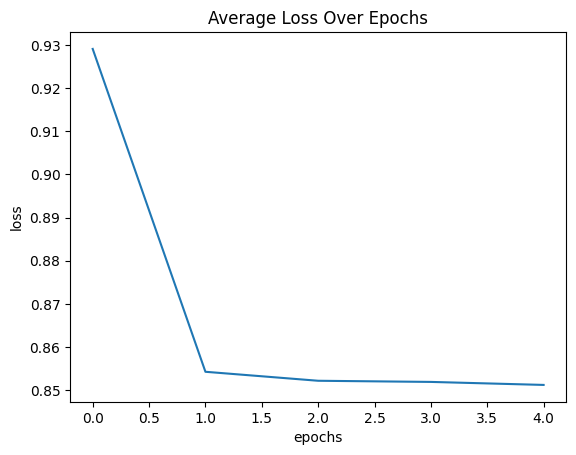

In [25]:
plt.plot(average_loss)
plt.xlabel("epochs")
plt.ylabel("loss")
plt.title("Average Loss Over Epochs")
plt.show()

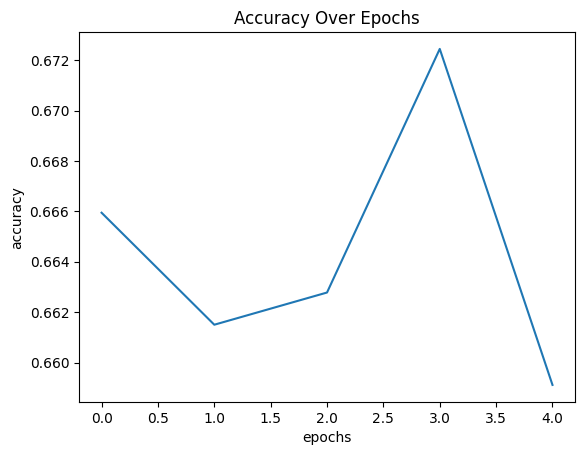

In [26]:
plt.plot(accuracy_epochs)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.title("Accuracy Over Epochs")
plt.show()

## **Step 6: Model Prediction**

In [59]:
def model_predict (model, text, offset):
    
    offset_tenosr = torch.tensor(offset, dtype=torch.int64)
    text_indices = text_pipeline(text)
    text_tensor = torch.tensor(text_indices, dtype=torch.long)
    print(text_tensor)
    print(offset_tenosr)
    
    model.eval()
    with torch.no_grad():
    
        predict = model(text_tensor, offset_tenosr)
        probabilities_label = torch.softmax(predict,dim=1).squeeze(0)
        
    top_probs = torch.argmax(probabilities_label,dim=0)
    
    print(probabilities_label)
    print(top_probs)
    
    # mapping with ag_news labels
    predict_label = ag_news_label[top_probs.item()+1]
    
    return predict_label

In [62]:
offset = [0, 9]
text = """US President signs new foreign policy agreement with European allies
Sri Lanka declares economic emergency amid financial crisis"""

model_predict(model,text,offset)

tensor([   95,    90,  1867,    50,   205,   527,   547,    17,   291,  2186,
         1761,  2460, 11546,   251,  1357,  1351,   395,   721])
tensor([0, 9])
tensor([0.8298, 0.1282, 0.0244, 0.0176])
tensor(0)


'World'